# **Install Required Libraries**

In [1]:
!pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.8 MB/s eta 0:00:00


# **Memory Configuration and Imports**

In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True"
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import gc
import random
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

# **Mount Google Drive**

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# **Set Random Seed and Check GPU**

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)


if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

    print(
        "GPU detected:",
        torch.cuda.get_device_name(0)
    )

else:

    DEVICE = torch.device("cpu")

    print(
        "GPU not detected. Change the Colab "
        "runtime type to T4 GPU."
    )


print("Selected device:", DEVICE)

GPU detected: Tesla T4
Selected device: cuda


# **Load Preprocessed Dataset**

In [6]:
DATA_PATH = (
    "/content/drive/MyDrive/"
    "spotify_preprocessed_output/"
    "spotify_reviews_embedding_dataset.csv"
)


if not os.path.exists(DATA_PATH):

    raise FileNotFoundError(
        f"Dataset was not found:\n{DATA_PATH}"
    )


df_distilbert = pd.read_csv(
    DATA_PATH,
    low_memory=False
)


print("Original loaded shape:", df_distilbert.shape)

print(
    "Columns:",
    df_distilbert.columns.tolist()
)

display(
    df_distilbert.head()
)

Original loaded shape: (65978, 5)
Columns: ['global_index_id', 'custom_id', 'review_text', 'rating_score', 'rating_scale']


,global_index_id,custom_id,review_text,rating_score,rating_scale
0,review_1,ds1_1,perfect,5,positive
1,review_2,ds1_2,nice app,1,negative
2,review_3,ds1_3,using mostly for bible podcast n prayers. very...,5,positive
3,review_4,ds1_4,it understands music taste and quality of soun...,5,positive
4,review_5,ds1_5,its very helpful especially to music lovers li...,5,positive


# **Check and Clean Required Columns**

In [7]:
required_columns = [
    "review_text",
    "rating_scale"
]


missing_columns = [
    column
    for column in required_columns
    if column not in df_distilbert.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# Standardize review text
df_distilbert["review_text"] = (
    df_distilbert["review_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# Standardize class labels
df_distilbert["rating_scale"] = (
    df_distilbert["rating_scale"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)


# Remove blank reviews
df_distilbert = df_distilbert[
    df_distilbert["review_text"] != ""
].copy()


# Keep only negative and positive reviews
df_distilbert = df_distilbert[
    df_distilbert["rating_scale"].isin(
        ["negative", "positive"]
    )
].copy()


# Preserve the existing row order
df_distilbert.reset_index(
    drop=True,
    inplace=True
)


print(
    "Final binary dataset shape:",
    df_distilbert.shape
)


print(
    "\nBinary class distribution:"
)

print(
    df_distilbert[
        "rating_scale"
    ].value_counts()
)

Final binary dataset shape: (65978, 5)

Binary class distribution:
rating_scale
positive    37548
negative    28430
Name: count, dtype: int64


# **Create the 80:10:10 Split**

In [8]:
X_emb = df_distilbert[
    "review_text"
]

y_emb = df_distilbert[
    "rating_scale"
]


# First split:
# 80% training and 20% temporary
(
    X_train_emb,
    X_temp_emb,
    y_train_emb,
    y_temp_emb
) = train_test_split(

    X_emb,
    y_emb,

    test_size=0.20,

    random_state=SEED,

    stratify=y_emb,

    shuffle=True
)


# Second split:
# Temporary data becomes 10% validation and 10% test
(
    X_val_emb,
    X_test_emb,
    y_val_emb,
    y_test_emb
) = train_test_split(

    X_temp_emb,
    y_temp_emb,

    test_size=0.50,

    random_state=SEED,

    stratify=y_temp_emb,

    shuffle=True
)


print("DistilBERT Split:")

print(
    f"Train: {len(X_train_emb)}"
)

print(
    f"Validation: {len(X_val_emb)}"
)

print(
    f"Test: {len(X_test_emb)}"
)

DistilBERT Split:
Train: 52782
Validation: 6598
Test: 6598


# **Check Class Distribution in Each Split**

In [9]:
def display_class_distribution(
    name,
    labels
):

    print(f"\n{name}")

    print(
        labels.value_counts()
    )

    print(
        labels.value_counts(
            normalize=True
        ).round(4)
    )


display_class_distribution(
    "Training set",
    y_train_emb
)

display_class_distribution(
    "Validation set",
    y_val_emb
)

display_class_distribution(
    "Test set",
    y_test_emb
)


Training set
rating_scale
positive    30038
negative    22744
Name: count, dtype: int64
rating_scale
positive    0.5691
negative    0.4309
Name: proportion, dtype: float64

Validation set
rating_scale
positive    3755
negative    2843
Name: count, dtype: int64
rating_scale
positive    0.5691
negative    0.4309
Name: proportion, dtype: float64

Test set
rating_scale
positive    3755
negative    2843
Name: count, dtype: int64
rating_scale
positive    0.5691
negative    0.4309
Name: proportion, dtype: float64


# **Encode Labels**

In [10]:
le_emb = LabelEncoder()


# Fit only on training labels
y_train_emb_enc = le_emb.fit_transform(
    y_train_emb
)


# Apply the same encoder
y_val_emb_enc = le_emb.transform(
    y_val_emb
)

y_test_emb_enc = le_emb.transform(
    y_test_emb
)


CLASS_NAMES = list(
    le_emb.classes_
)

NUM_LABELS = len(
    CLASS_NAMES
)


print("Label mapping:")

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"{class_id} = {class_name}"
    )


print(
    "\nNumber of classes:",
    NUM_LABELS
)

Label mapping:
0 = negative
1 = positive

Number of classes: 2


# **Class Weights Calculation**

In [11]:
encoded_classes = np.unique(
    y_train_emb_enc
)


class_weights_emb = compute_class_weight(

    class_weight="balanced",

    classes=encoded_classes,

    y=y_train_emb_enc
)


class_weight_dict_emb = {

    int(class_id): float(weight)

    for class_id, weight in zip(
        encoded_classes,
        class_weights_emb
    )
}


distilbert_class_weights = [

    class_weight_dict_emb[
        class_id
    ]

    for class_id in range(
        NUM_LABELS
    )
]


print(
    "Class-weight dictionary:",
    class_weight_dict_emb
)


print(
    "Ordered DistilBERT weights:",
    distilbert_class_weights
)

Class-weight dictionary: {0: 1.1603499824129442, 1: 0.8785871229775618}
Ordered DistilBERT weights: [1.1603499824129442, 0.8785871229775618]


# **Create Hugging Face Datasets**

In [12]:
distilbert_train_dataset = Dataset.from_dict({

    "text": (
        X_train_emb
        .astype(str)
        .tolist()
    ),

    "labels": (
        np.asarray(
            y_train_emb_enc,
            dtype=np.int64
        )
        .tolist()
    )
})


distilbert_val_dataset = Dataset.from_dict({

    "text": (
        X_val_emb
        .astype(str)
        .tolist()
    ),

    "labels": (
        np.asarray(
            y_val_emb_enc,
            dtype=np.int64
        )
        .tolist()
    )
})


print(
    distilbert_train_dataset
)

print(
    distilbert_val_dataset
)


print("\nFirst training example:")

print(
    distilbert_train_dataset[0]
)

Dataset({
    features: ['text', 'labels'],
    num_rows: 52782
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 6598
})

First training example:
{'text': "i joined spotify for the music but i increasingly use it for podcasts and news shows. i have learned about many new artists and podcasts through spotify's algorithms and i am very grateful for that. it is hard for me to imagine life without spotify, i am on it every single day. having said that, there are still some gaps in the music and i wish spotify would be more proactive in closing these, instead of telling customers to contact record labels to tell them to upload an album.", 'labels': 1}


# **Load DistilBERT Tokenizer**

In [13]:
DISTILBERT_MODEL_NAME = (
    "distilbert/distilbert-base-uncased"
)


# Lower than 128 to reduce GPU memory usage
DISTILBERT_MAX_LENGTH = 96


distilbert_tokenizer = (
    AutoTokenizer.from_pretrained(

        DISTILBERT_MODEL_NAME,

        use_fast=True
    )
)


print(
    "Tokenizer loaded:",
    DISTILBERT_MODEL_NAME
)


print(
    "Maximum token length:",
    DISTILBERT_MAX_LENGTH
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert/distilbert-base-uncased
Maximum token length: 96


# **Tokenize the Reviews**

In [14]:
def tokenize_distilbert_reviews(
    batch
):

    return distilbert_tokenizer(

        batch["text"],

        truncation=True,

        max_length=(
            DISTILBERT_MAX_LENGTH
        )
    )


tokenized_distilbert_train = (

    distilbert_train_dataset.map(

        tokenize_distilbert_reviews,

        batched=True,

        remove_columns=["text"],

        desc=(
            "Tokenizing training reviews"
        )
    )
)


tokenized_distilbert_val = (

    distilbert_val_dataset.map(

        tokenize_distilbert_reviews,

        batched=True,

        remove_columns=["text"],

        desc=(
            "Tokenizing validation reviews"
        )
    )
)


print(
    tokenized_distilbert_train
)

print(
    tokenized_distilbert_val
)

Tokenizing training reviews:   0%|          | 0/52782 [00:00<?, ? examples/s]

Tokenizing validation reviews:   0%|          | 0/6598 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 52782
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6598
})


# **Create Dynamic Padding**

In [15]:
distilbert_data_collator = (
    DataCollatorWithPadding(

        tokenizer=(
            distilbert_tokenizer
        ),

        return_tensors="pt"
    )
)


print(
    "Dynamic padding created."
)

Dynamic padding created.


# **Create Label Mappings**

In [16]:
distilbert_id2label = {

    class_id: class_name

    for class_id, class_name
    in enumerate(CLASS_NAMES)
}


distilbert_label2id = {

    class_name: class_id

    for class_id, class_name
    in enumerate(CLASS_NAMES)
}


print(
    "ID to label:",
    distilbert_id2label
)


print(
    "Label to ID:",
    distilbert_label2id
)

ID to label: {0: 'negative', 1: 'positive'}
Label to ID: {'negative': 0, 'positive': 1}


# **Load Fresh DistilBERT Model**

In [17]:
gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


distilbert_model = (

    AutoModelForSequenceClassification
    .from_pretrained(

        DISTILBERT_MODEL_NAME,

        num_labels=NUM_LABELS,

        id2label=(
            distilbert_id2label
        ),

        label2id=(
            distilbert_label2id
        ),

        problem_type=(
            "single_label_classification"
        )
    )
)


# Reduce GPU activation memory
distilbert_model.gradient_checkpointing_enable()


print(
    "DistilBERT model loaded."
)


print(
    "Number of labels:",
    distilbert_model.config.num_labels
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded.
Number of labels: 2


# **Define Validation Metrics**

In [18]:
def compute_distilbert_metrics(
    evaluation_prediction
):

    predictions, true_labels = (
        evaluation_prediction
    )


    predicted_labels = np.argmax(
        predictions,
        axis=-1
    )


    return {

        "accuracy": accuracy_score(
            true_labels,
            predicted_labels
        ),

        "weighted_f1": f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0
        ),

        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    }

# **Create a Class-Weighted Trainer**

In [19]:
class ClassWeightedTrainer(Trainer):

    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs
    ):

        super().__init__(
            *args,
            **kwargs
        )


        if class_weights is None:

            raise ValueError(
                "Class weights must be provided."
            )


        self.class_weights = torch.tensor(

            class_weights,

            dtype=torch.float32
        )


        # Trainer will handle gradient accumulation
        self.model_accepts_loss_kwargs = False


    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.pop(
            "labels"
        )


        outputs = model(
            **inputs
        )


        logits = outputs.logits


        loss_function = (
            torch.nn.CrossEntropyLoss(

                weight=(
                    self.class_weights
                    .to(logits.device)
                )
            )
        )


        loss = loss_function(

            logits.view(
                -1,
                model.config.num_labels
            ),

            labels.view(-1)
        )


        if return_outputs:

            return loss, outputs


        return loss

# **Create Training Configuration**

In [20]:
import os
import torch


DISTILBERT_BASE_DIR = (
    "/content/drive/MyDrive/"
    "spotify_preprocessed_output/"
    "distilbert_binary"
)


DISTILBERT_CHECKPOINT_DIR = os.path.join(
    DISTILBERT_BASE_DIR,
    "checkpoints"
)


DISTILBERT_FINAL_MODEL_DIR = os.path.join(
    DISTILBERT_BASE_DIR,
    "best_model"
)


# Create the required folders
os.makedirs(
    DISTILBERT_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    DISTILBERT_FINAL_MODEL_DIR,
    exist_ok=True
)


distilbert_training_arguments = TrainingArguments(

    # Folder used to store checkpoints
    output_dir=DISTILBERT_CHECKPOINT_DIR,

    # Evaluate after every epoch
    eval_strategy="epoch",

    # Save after every epoch
    save_strategy="epoch",

    # Fine-tuning settings
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.10,

    # Memory-efficient batch settings
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,

    # Effective batch size:
    # 4 physical samples × 4 accumulation steps = 16
    gradient_accumulation_steps=4,

    # Reduce GPU memory usage
    gradient_checkpointing=True,

    # Move evaluation predictions to CPU gradually
    eval_accumulation_steps=4,

    # Restore the checkpoint with the best validation result
    load_best_model_at_end=True,

    metric_for_best_model="weighted_f1",

    greater_is_better=True,

    # Keep only two checkpoints
    save_total_limit=2,

    # Logging settings
    logging_strategy="steps",
    logging_steps=100,

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    # T4 GPU mixed-precision training
    fp16=torch.cuda.is_available(),

    # Optimizer
    optim="adamw_torch",

    # Disable external reporting
    report_to="none",

    # Do not upload to Hugging Face
    push_to_hub=False
)


print("Training configuration created successfully.")

print(
    "Checkpoint folder:",
    DISTILBERT_CHECKPOINT_DIR
)

print(
    "Final model folder:",
    DISTILBERT_FINAL_MODEL_DIR
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration created successfully.
Checkpoint folder: /content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/checkpoints
Final model folder: /content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/best_model


# **Create the Trainer**

In [21]:
distilbert_trainer = ClassWeightedTrainer(

    model=distilbert_model,

    args=(
        distilbert_training_arguments
    ),

    train_dataset=(
        tokenized_distilbert_train
    ),

    eval_dataset=(
        tokenized_distilbert_val
    ),

    processing_class=(
        distilbert_tokenizer
    ),

    data_collator=(
        distilbert_data_collator
    ),

    compute_metrics=(
        compute_distilbert_metrics
    ),

    class_weights=(
        distilbert_class_weights
    ),

    callbacks=[

        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)


print(
    "DistilBERT Trainer created."
)

DistilBERT Trainer created.


# **Check GPU Memory Before Training**

In [22]:
if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


    print(
        "Allocated memory:",
        round(
            torch.cuda.memory_allocated(0)
            / 1024**3,
            2
        ),
        "GB"
    )


    print(
        "Reserved memory:",
        round(
            torch.cuda.memory_reserved(0)
            / 1024**3,
            2
        ),
        "GB"
    )

GPU: Tesla T4
Allocated memory: 0.25 GB
Reserved memory: 0.26 GB


# **Fine-Tune DistilBERT**

In [23]:
distilbert_training_result = (
    distilbert_trainer.train()
)


print(
    "\nDistilBERT fine-tuning completed."
)

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,0.240979,0.262723,0.914216,0.914576,0.913452
2,0.179229,0.222894,0.923765,0.923960,0.922715
3,0.144108,0.254069,0.923916,0.924097,0.922832


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT fine-tuning completed.


# **Display Training Summary**

In [24]:
print(
    "DistilBERT training summary:\n"
)


for metric_name, metric_value in (
    distilbert_training_result
    .metrics
    .items()
):

    print(
        f"{metric_name}: {metric_value}"
    )

DistilBERT training summary:

train_runtime: 2726.7663
train_samples_per_second: 58.071
train_steps_per_second: 3.63
total_flos: 2573824480010472.0
train_loss: 0.20927163496322918
epoch: 3.0


# **Predict the Validation Set**

In [25]:
distilbert_validation_output = (
    distilbert_trainer.predict(
        tokenized_distilbert_val
    )
)


y_val_pred_distilbert = np.argmax(

    distilbert_validation_output.predictions,

    axis=-1
)


y_val_true_distilbert = np.asarray(

    y_val_emb_enc,

    dtype=np.int64
)


print(
    "Validation predictions:",
    len(y_val_pred_distilbert)
)

Validation predictions: 6598


# **Validation Evaluation**

In [26]:
distilbert_val_accuracy = accuracy_score(

    y_val_true_distilbert,

    y_val_pred_distilbert
)


distilbert_val_weighted_f1 = f1_score(

    y_val_true_distilbert,

    y_val_pred_distilbert,

    average="weighted",

    zero_division=0
)


distilbert_val_macro_f1 = f1_score(

    y_val_true_distilbert,

    y_val_pred_distilbert,

    average="macro",

    zero_division=0
)


print(
    "=== DISTILBERT VALIDATION RESULTS ==="
)


print(
    f"Accuracy: {distilbert_val_accuracy:.6f}"
)


print(
    "Weighted F1-score:",
    f"{distilbert_val_weighted_f1:.6f}"
)


print(
    f"Macro F1-score: "
    f"{distilbert_val_macro_f1:.6f}"
)


print("\nClassification Report:\n")


print(
    classification_report(

        y_val_true_distilbert,

        y_val_pred_distilbert,

        labels=np.arange(
            NUM_LABELS
        ),

        target_names=CLASS_NAMES,

        zero_division=0
    )
)

=== DISTILBERT VALIDATION RESULTS ===
Accuracy: 0.923916
Weighted F1-score: 0.924097
Macro F1-score: 0.922832

Classification Report:

              precision    recall  f1-score   support

    negative       0.89      0.93      0.91      2843
    positive       0.95      0.92      0.93      3755

    accuracy                           0.92      6598
   macro avg       0.92      0.93      0.92      6598
weighted avg       0.92      0.92      0.92      6598



# **Validation Confusion Matrix**

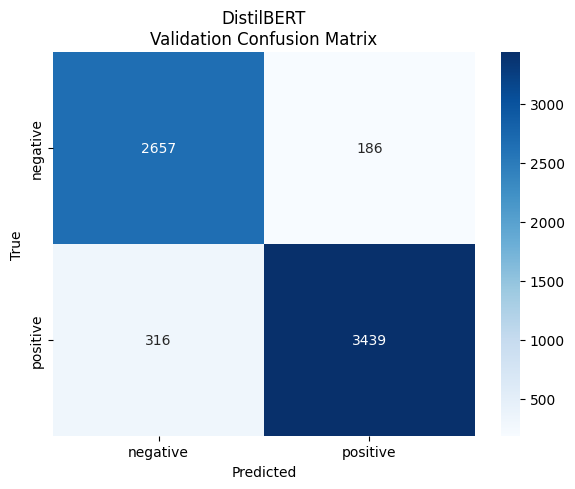

In [27]:
distilbert_val_cm = confusion_matrix(

    y_val_true_distilbert,

    y_val_pred_distilbert,

    labels=np.arange(
        NUM_LABELS
    )
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(

    distilbert_val_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)


plt.title(
    "DistilBERT\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

# **Save the Best Model**

In [28]:
distilbert_trainer.save_model(
    DISTILBERT_FINAL_MODEL_DIR
)


distilbert_tokenizer.save_pretrained(
    DISTILBERT_FINAL_MODEL_DIR
)


print(
    "Best model saved to:"
)

print(
    DISTILBERT_FINAL_MODEL_DIR
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to:
/content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/best_model


# **Save Validation Predictions**

In [29]:
distilbert_validation_results = pd.DataFrame({

    "review_text": (
        X_val_emb
        .astype(str)
        .to_numpy()
    ),

    "true_label_encoded": (
        y_val_true_distilbert
    ),

    "predicted_label_encoded": (
        y_val_pred_distilbert
    ),

    "true_label": (
        le_emb.inverse_transform(
            y_val_true_distilbert
        )
    ),

    "predicted_label": (
        le_emb.inverse_transform(
            y_val_pred_distilbert
        )
    )
})


distilbert_validation_results[
    "correct_prediction"
] = (

    distilbert_validation_results[
        "true_label_encoded"
    ]

    ==

    distilbert_validation_results[
        "predicted_label_encoded"
    ]
)


VALIDATION_PREDICTIONS_PATH = os.path.join(

    DISTILBERT_BASE_DIR,

    "distilbert_validation_predictions.csv"
)


distilbert_validation_results.to_csv(

    VALIDATION_PREDICTIONS_PATH,

    index=False
)


display(
    distilbert_validation_results.head(10)
)


print(
    "Validation predictions saved to:"
)

print(
    VALIDATION_PREDICTIONS_PATH
)

,review_text,true_label_encoded,predicted_label_encoded,true_label,predicted_label,correct_prediction
0,"so . suddenly, any and all r slash podcasts ju...",0,0,negative,negative,True
1,"worst app i have, takes 30 seconds to load an ...",0,0,negative,negative,True
2,sound quality is horrible compared with compet...,0,0,negative,negative,True
3,spotify is usually pretty good but they have r...,1,0,positive,negative,False
4,i can download songs but i used to play it on ...,0,0,negative,negative,True
5,disappointing i am a paying user of this app. ...,0,0,negative,negative,True
6,nice 🥀🥀😍🥰,0,1,negative,positive,False
7,i dont like your playlists and have turned off...,0,0,negative,negative,True
8,listening to songs on this app is just toi smo...,1,1,positive,positive,True
9,love spotify but the play bar disappears rando...,0,1,negative,positive,False


Validation predictions saved to:
/content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/distilbert_validation_predictions.csv


# **Save Validation Summary**

In [30]:
distilbert_validation_summary = pd.DataFrame({

    "Algorithm": [
        "DistilBERT"
    ],

    "Representation": [
        "Built-in Transformer Representation"
    ],

    "Dataset": [
        "Preprocessed Binary Dataset"
    ],

    "Evaluation_Set": [
        "Validation"
    ],

    "Accuracy": [
        distilbert_val_accuracy
    ],

    "Weighted_F1": [
        distilbert_val_weighted_f1
    ],

    "Macro_F1": [
        distilbert_val_macro_f1
    ]
})


VALIDATION_SUMMARY_PATH = os.path.join(

    DISTILBERT_BASE_DIR,

    "distilbert_validation_summary.csv"
)


distilbert_validation_summary.to_csv(

    VALIDATION_SUMMARY_PATH,

    index=False
)


display(
    distilbert_validation_summary
)


print(
    "Validation summary saved to:"
)

print(
    VALIDATION_SUMMARY_PATH
)

,Algorithm,Representation,Dataset,Evaluation_Set,Accuracy,Weighted_F1,Macro_F1
0,DistilBERT,Built-in Transformer Representation,Preprocessed Binary Dataset,Validation,0.923916,0.924097,0.922832


Validation summary saved to:
/content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/distilbert_validation_summary.csv


# **Test Set Evaluation**

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from datasets import Dataset

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Test-analysis libraries imported successfully.")

## **Create Test Dataset**

In [31]:
distilbert_test_dataset = Dataset.from_dict({

    "text": (
        X_test_emb
        .astype(str)
        .tolist()
    ),

    "labels": (
        np.asarray(
            y_test_emb_enc,
            dtype=np.int64
        )
        .tolist()
    )
})


print(distilbert_test_dataset)

print("\nFirst test example:")

print(
    distilbert_test_dataset[0]
)

Dataset({
    features: ['text', 'labels'],
    num_rows: 6598
})

First test example:
{'text': 'i love this app because i can listen to my favorite songs and listen to podcasts❤💞🥰🤩', 'labels': 1}


This converts the untouched test data into a Hugging Face **Dataset**.

## **Tokenise Test Reviews**

In [32]:
tokenized_distilbert_test = (
    distilbert_test_dataset.map(

        tokenize_distilbert_reviews,

        batched=True,

        remove_columns=["text"],

        desc="Tokenizing test reviews"
    )
)


print(tokenized_distilbert_test)

print(
    "\nNumber of tokenized test reviews:",
    len(tokenized_distilbert_test)
)

Tokenizing test reviews:   0%|          | 0/6598 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6598
})

Number of tokenized test reviews: 6598


This uses the same **distilbert_tokenizer** and tokenization function that were used for the training and validation data.

Each review is converted into:
* **input_ids**: numerical token identifiers.
* **attention_mask**: identifies real tokens and padding tokens.
* **labels**: the actual encoded sentiment.

## **DistilBERT Test Prediction**

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from datasets import Dataset

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Test-analysis libraries imported successfully.")

Test-analysis libraries imported successfully.


In [37]:
distilbert_test_output = (
    distilbert_trainer.predict(
        tokenized_distilbert_test
    )
)


# Raw output scores from DistilBERT
distilbert_test_logits = (
    distilbert_test_output.predictions
)


# Select the class with the highest score
y_test_pred_distilbert = np.argmax(
    distilbert_test_logits,
    axis=-1
)


# Actual test labels
y_test_true_distilbert = np.asarray(
    y_test_emb_enc,
    dtype=np.int64
)


print(
    "Test predictions completed:",
    len(y_test_pred_distilbert)
)

print(
    "Actual test labels:",
    len(y_test_true_distilbert)
)

Test predictions completed: 6598
Actual test labels: 6598


* **distilbert_trainer.predict()** applies the fine-tuned DistilBERT model to every test review.
* Two raw scores based on classes:
  * 0 = negative
  * 1 = positive
* **np.argmac()** selects the class with the larger score

## **Calculation of Prediction Probabilities**

In [38]:
# Numerically stable softmax calculation
shifted_logits = (
    distilbert_test_logits
    - np.max(
        distilbert_test_logits,
        axis=1,
        keepdims=True
    )
)

exponential_logits = np.exp(
    shifted_logits
)

distilbert_test_probabilities = (
    exponential_logits
    / np.sum(
        exponential_logits,
        axis=1,
        keepdims=True
    )
)


# Highest probability becomes prediction confidence
distilbert_test_confidence = np.max(
    distilbert_test_probabilities,
    axis=1
)


# Find the encoded value of the positive class
positive_class_id = int(
    le_emb.transform(
        ["positive"]
    )[0]
)


# Obtain the positive probability
distilbert_positive_probability = (
    distilbert_test_probabilities[
        :,
        positive_class_id
    ]
)


print(
    "Probability matrix shape:",
    distilbert_test_probabilities.shape
)

print(
    "Average prediction confidence:",
    round(
        float(
            distilbert_test_confidence.mean()
        ),
        4
    )
)

Probability matrix shape: (6598, 2)
Average prediction confidence: 0.9774


## **Final DistilBERT Test Metrics**

In [39]:
distilbert_test_accuracy = accuracy_score(
    y_test_true_distilbert,
    y_test_pred_distilbert
)


distilbert_test_weighted_precision = precision_score(
    y_test_true_distilbert,
    y_test_pred_distilbert,
    average="weighted",
    zero_division=0
)


distilbert_test_weighted_recall = recall_score(
    y_test_true_distilbert,
    y_test_pred_distilbert,
    average="weighted",
    zero_division=0
)


distilbert_test_weighted_f1 = f1_score(
    y_test_true_distilbert,
    y_test_pred_distilbert,
    average="weighted",
    zero_division=0
)


distilbert_test_macro_f1 = f1_score(
    y_test_true_distilbert,
    y_test_pred_distilbert,
    average="macro",
    zero_division=0
)


binary_test_labels = (
    y_test_true_distilbert
    == positive_class_id
).astype(int)


distilbert_test_roc_auc = roc_auc_score(
    binary_test_labels,
    distilbert_positive_probability
)


distilbert_test_summary = pd.DataFrame({

    "Model": [
        "DistilBERT"
    ],

    "Test Accuracy": [
        distilbert_test_accuracy
    ],

    "Weighted Precision": [
        distilbert_test_weighted_precision
    ],

    "Weighted Recall": [
        distilbert_test_weighted_recall
    ],

    "Weighted F1": [
        distilbert_test_weighted_f1
    ],

    "Macro F1": [
        distilbert_test_macro_f1
    ],

    "ROC-AUC": [
        distilbert_test_roc_auc
    ]
})


display(
    distilbert_test_summary.round(4)
)

,Model,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,ROC-AUC
0,DistilBERT,0.9253,0.9267,0.9253,0.9255,0.9243,0.969


* **Accuracy**: Overall percentage of correctly predicted reviews.
* **Weighted Precision**: Precision adjusted for class size.
* **Weighted Recall**: Recall adjusted for class size.
* **Weighted F1-Score**: Balance between weighted precision and recall.
* **Macro F1-score**: Gives equal importance to both classes.
* **ROC-AUC**: Measures how well DistilBERT separates positive and negative reviews across different decision thresholds.

## **Comparison Validation and Test Results**

In [40]:
distilbert_validation_test_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Weighted F1",
        "Macro F1"
    ],

    "Validation": [
        distilbert_val_accuracy,
        distilbert_val_weighted_f1,
        distilbert_val_macro_f1
    ],

    "Test": [
        distilbert_test_accuracy,
        distilbert_test_weighted_f1,
        distilbert_test_macro_f1
    ]
})


distilbert_validation_test_comparison[
    "Difference"
] = (
    distilbert_validation_test_comparison[
        "Test"
    ]
    -
    distilbert_validation_test_comparison[
        "Validation"
    ]
)


distilbert_validation_test_comparison[
    "Difference in Percentage Points"
] = (
    distilbert_validation_test_comparison[
        "Difference"
    ]
    * 100
)


display(
    distilbert_validation_test_comparison.round(4)
)

,Metric,Validation,Test,Difference,Difference in Percentage Points
0,Accuracy,0.9239,0.9253,0.0014,0.1364
1,Weighted F1,0.9241,0.9255,0.0014,0.1388
2,Macro F1,0.9228,0.9243,0.0015,0.1451


## **Plot Validation and Test Results**

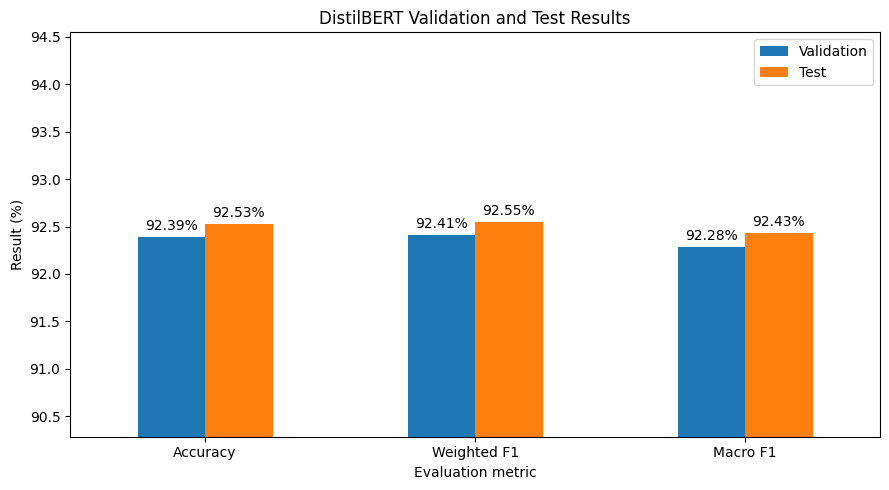

In [41]:
comparison_plot_data = (
    distilbert_validation_test_comparison[
        [
            "Metric",
            "Validation",
            "Test"
        ]
    ]
    .set_index("Metric")
    .mul(100)
)


axis = comparison_plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)


all_values = comparison_plot_data.to_numpy()

minimum_value = all_values.min()
maximum_value = all_values.max()


axis.set_ylim(
    max(0, minimum_value - 2),
    min(100, maximum_value + 2)
)


axis.set_title(
    "DistilBERT Validation and Test Results"
)

axis.set_xlabel("Evaluation metric")
axis.set_ylabel("Result (%)")

plt.xticks(
    rotation=0
)


for container in axis.containers:

    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )


plt.tight_layout()
plt.show()

## **Test Classification Report**

In [42]:
print(
    "=== DISTILBERT TEST CLASSIFICATION REPORT ===\n"
)


print(
    classification_report(

        y_test_true_distilbert,

        y_test_pred_distilbert,

        labels=np.arange(
            NUM_LABELS
        ),

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0
    )
)


distilbert_test_report_df = pd.DataFrame(

    classification_report(

        y_test_true_distilbert,

        y_test_pred_distilbert,

        labels=np.arange(
            NUM_LABELS
        ),

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )

).transpose()


display(
    distilbert_test_report_df.round(4)
)

=== DISTILBERT TEST CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative     0.8919    0.9406    0.9156      2843
    positive     0.9531    0.9137    0.9330      3755

    accuracy                         0.9253      6598
   macro avg     0.9225    0.9271    0.9243      6598
weighted avg     0.9267    0.9253    0.9255      6598



,precision,recall,f1-score,support
negative,0.8919,0.9406,0.9156,2843.0000
positive,0.9531,0.9137,0.9330,3755.0000
accuracy,0.9253,0.9253,0.9253,0.9253
macro avg,0.9225,0.9271,0.9243,6598.0000
weighted avg,0.9267,0.9253,0.9255,6598.0000


The report displays separate results for negative and positive reviews:

* Precision
* Recall
* F1-score
* Support

This helps determine whether the overall accuracy represents good performance for both sentiment classes.

## **Count Confusion Matrix**

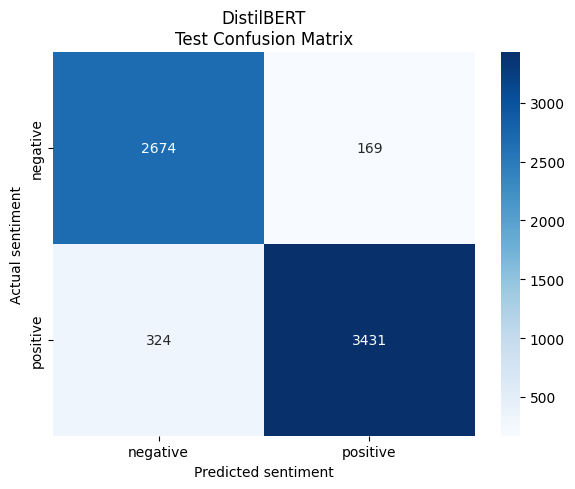

Confusion matrix:
 [[2674  169]
 [ 324 3431]]


In [43]:
distilbert_test_cm = confusion_matrix(

    y_test_true_distilbert,

    y_test_pred_distilbert,

    labels=np.arange(
        NUM_LABELS
    )
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(

    distilbert_test_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)


plt.title(
    "DistilBERT\n"
    "Test Confusion Matrix"
)

plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")

plt.tight_layout()
plt.show()


print(
    "Confusion matrix:\n",
    distilbert_test_cm
)

## **Normalised Confusion Matrix**

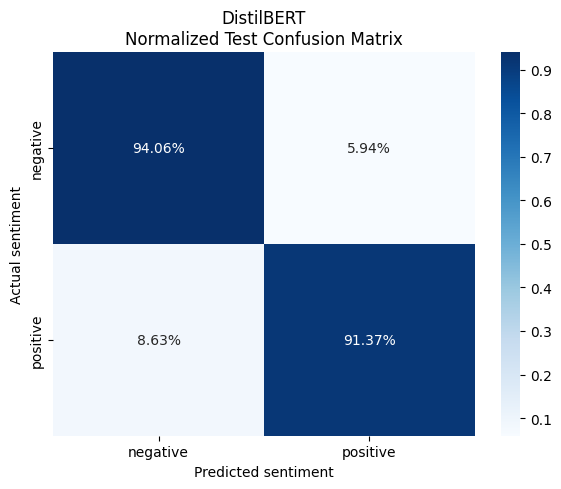

In [44]:
distilbert_test_cm_normalized = confusion_matrix(

    y_test_true_distilbert,

    y_test_pred_distilbert,

    labels=np.arange(
        NUM_LABELS
    ),

    normalize="true"
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(

    distilbert_test_cm_normalized,

    annot=True,

    fmt=".2%",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)


plt.title(
    "DistilBERT\n"
    "Normalized Test Confusion Matrix"
)

plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")

plt.tight_layout()
plt.show()

## **Detailed Test Prediction Table**

In [45]:
distilbert_test_results = pd.DataFrame({

    "test_row": np.arange(
        len(y_test_true_distilbert)
    ),

    "review_text": (
        X_test_emb
        .astype(str)
        .reset_index(drop=True)
        .to_numpy()
    ),

    "true_label_encoded": (
        y_test_true_distilbert
    ),

    "predicted_label_encoded": (
        y_test_pred_distilbert
    ),

    "true_label": (
        le_emb.inverse_transform(
            y_test_true_distilbert
        )
    ),

    "predicted_label": (
        le_emb.inverse_transform(
            y_test_pred_distilbert
        )
    ),

    "negative_probability": (
        distilbert_test_probabilities[
            :,
            int(
                le_emb.transform(
                    ["negative"]
                )[0]
            )
        ]
    ),

    "positive_probability": (
        distilbert_positive_probability
    ),

    "confidence": (
        distilbert_test_confidence
    )
})


distilbert_test_results[
    "correct_prediction"
] = (
    distilbert_test_results[
        "true_label_encoded"
    ]
    ==
    distilbert_test_results[
        "predicted_label_encoded"
    ]
)


distilbert_test_results[
    "error_type"
] = np.where(

    distilbert_test_results[
        "correct_prediction"
    ],

    "Correct",

    distilbert_test_results[
        "true_label"
    ].astype(str)

    + " → "

    + distilbert_test_results[
        "predicted_label"
    ].astype(str)
)


distilbert_test_results[
    "word_count"
] = (
    distilbert_test_results[
        "review_text"
    ]
    .str.split()
    .str.len()
)


display(
    distilbert_test_results.head(10)
)

,test_row,review_text,true_label_encoded,predicted_label_encoded,true_label,predicted_label,negative_probability,positive_probability,confidence,correct_prediction,error_type,word_count
0,0,i love this app because i can listen to my fav...,1,1,positive,positive,0.003566,0.996434,0.996434,True,Correct,16
1,1,"gave me an ad for 30 mins. of ad free music, b...",0,0,negative,negative,0.991938,0.008062,0.991938,True,Correct,22
2,2,much love. this app is my favorite when it com...,1,1,positive,positive,0.001362,0.998638,0.998638,True,Correct,24
3,3,i do heavily enjoy spotify - the fact of free ...,1,1,positive,positive,0.002364,0.997636,0.997636,True,Correct,52
4,4,love the new and the old songs in the past. br...,1,1,positive,positive,0.001097,0.998903,0.998903,True,Correct,37
5,5,i cannot shuffle through my own liked songs at...,0,0,negative,negative,0.992481,0.007519,0.992481,True,Correct,43
6,6,great array of good music,1,1,positive,positive,0.001073,0.998927,0.998927,True,Correct,5
7,7,they know my taste of music and always made a ...,1,1,positive,positive,0.000947,0.999053,0.999053,True,Correct,14
8,8,for years the app was basically flawless. howe...,0,0,negative,negative,0.991748,0.008252,0.991748,True,Correct,85
9,9,real awesome. love how at the end of the year ...,1,1,positive,positive,0.001389,0.998611,0.998611,True,Correct,94


Every Test Review includes:
* Review text
* Actual sentiment
* Predicted sentiment
* Negative probability
* Positive probability
* Prediction confidence
* True/False of Prediction
* Type of error
* Review length

## **Most Confident Incorrect Predictions**

In [46]:
distilbert_wrong_predictions = (

    distilbert_test_results[

        ~distilbert_test_results[
            "correct_prediction"
        ]

    ]

    .sort_values(
        "confidence",
        ascending=False
    )

    .reset_index(drop=True)
)


print(
    "Number of incorrect predictions:",
    len(distilbert_wrong_predictions)
)


display(

    distilbert_wrong_predictions.head(25)[

        [
            "review_text",
            "true_label",
            "predicted_label",
            "confidence",
            "negative_probability",
            "positive_probability",
            "error_type"
        ]

    ]
)

Number of incorrect predictions: 493


,review_text,true_label,predicted_label,confidence,negative_probability,positive_probability,error_type
0,it has every song you could possibly want and ...,negative,positive,0.999056,0.000944,0.999056,negative → positive
1,best playing music 🎶 👌 ever from the playlist ...,negative,positive,0.998974,0.001026,0.998974,negative → positive
2,definitely the best music streaming app. upd: ...,negative,positive,0.998711,0.001289,0.998711,negative → positive
3,why did you click on 1 ★? this is the best mus...,negative,positive,0.998652,0.001348,0.998652,negative → positive
4,"i searched for a song, tried to play it and sp...",negative,positive,0.998408,0.001592,0.998408,negative → positive
5,all i can play are playlist,negative,positive,0.998345,0.001655,0.998345,negative → positive
6,love the variety of music just really wish son...,negative,positive,0.998342,0.001658,0.998342,negative → positive
7,i do lots and lots of driving and i love music...,negative,positive,0.998197,0.001803,0.998197,negative → positive
8,best for listening,negative,positive,0.998158,0.001842,0.998158,negative → positive
9,this so good for when i go to sleep and i list...,negative,positive,0.998024,0.001976,0.998024,negative → positive


## **Define Brand-Reputation Themes**

In [47]:
import re
from collections import OrderedDict

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)


# Find the exact class names used by the LabelEncoder.
NEGATIVE_LABEL = next(
    class_name
    for class_name in CLASS_NAMES
    if str(class_name).lower() == "negative"
)

POSITIVE_LABEL = next(
    class_name
    for class_name in CLASS_NAMES
    if str(class_name).lower() == "positive"
)


# Researcher-defined Spotify reputation themes.
# One review may belong to more than one theme.
REPUTATION_THEMES = OrderedDict({

    "Music and content experience": [
        "music",
        "song",
        "songs",
        "artist",
        "artists",
        "album",
        "playlist",
        "playlists",
        "podcast",
        "podcasts",
        "lyrics",
        "library"
    ],

    "Playback and service reliability": [
        "playback",
        "cannot play",
        "can't play",
        "not play",
        "won't play",
        "stops playing",
        "stop playing",
        "buffering",
        "loading",
        "pause",
        "skip",
        "skipping",
        "shuffle",
        "offline",
        "download",
        "downloads"
    ],

    "Advertisements and free tier": [
        "ad",
        "ads",
        "advert",
        "adverts",
        "advertisement",
        "advertisements",
        "commercial",
        "commercials",
        "too many ads",
        "no ads",
        "ad free"
    ],

    "Premium subscription and value": [
        "premium",
        "subscription",
        "subscribe",
        "subscribed",
        "payment",
        "billing",
        "charged",
        "charge",
        "price",
        "pricing",
        "expensive",
        "cost",
        "refund",
        "free trial",
        "family plan",
        "student plan"
    ],

    "Application performance and updates": [
        "crash",
        "crashes",
        "crashed",
        "crashing",
        "freeze",
        "freezes",
        "frozen",
        "lag",
        "laggy",
        "slow",
        "bug",
        "bugs",
        "buggy",
        "glitch",
        "glitches",
        "update",
        "updates",
        "new update",
        "battery",
        "storage"
    ],

    "Account and access": [
        "login",
        "log in",
        "sign in",
        "account",
        "password",
        "verification",
        "verify",
        "locked",
        "disabled",
        "region",
        "country",
        "email"
    ],

    "Interface and usability": [
        "interface",
        "user interface",
        "ui",
        "design",
        "layout",
        "navigation",
        "navigate",
        "search",
        "easy to use",
        "user friendly",
        "difficult to use",
        "hard to use"
    ],

    "Personalisation and recommendations": [
        "recommendation",
        "recommendations",
        "recommended",
        "recommend",
        "personalised",
        "personalized",
        "discover weekly",
        "daily mix",
        "algorithm",
        "suggestion",
        "suggestions"
    ],

    "Customer support and problem resolution": [
        "customer service",
        "customer support",
        "support team",
        "help centre",
        "help center",
        "contact support",
        "response",
        "respond",
        "fix",
        "fixed",
        "resolve",
        "resolved"
    ]
})


THEME_BUSINESS_MEANING = {

    "Music and content experience":
        "Availability and enjoyment of Spotify's music, "
        "playlist, artist and podcast content.",

    "Playback and service reliability":
        "Reliability of streaming, song playback, downloads "
        "and offline listening.",

    "Advertisements and free tier":
        "User perception of advertisements and the limitations "
        "of Spotify's free service.",

    "Premium subscription and value":
        "Perceived value, pricing, billing and subscription "
        "experience.",

    "Application performance and updates":
        "Technical quality involving crashes, bugs, speed "
        "and software updates.",

    "Account and access":
        "Ability to sign in, manage accounts and access "
        "Spotify services.",

    "Interface and usability":
        "Ease of navigation, search, layout and general usage.",

    "Personalisation and recommendations":
        "Quality of personalised music discovery and "
        "recommendation features.",

    "Customer support and problem resolution":
        "Effectiveness of support, issue resolution and "
        "responses to user problems."
}


print("Number of reputation themes:", len(REPUTATION_THEMES))

for theme_name, keywords in REPUTATION_THEMES.items():

    print(
        f"{theme_name}: "
        f"{len(keywords)} keywords or phrases"
    )

Number of reputation themes: 9
Music and content experience: 12 keywords or phrases
Playback and service reliability: 16 keywords or phrases
Advertisements and free tier: 11 keywords or phrases
Premium subscription and value: 16 keywords or phrases
Application performance and updates: 20 keywords or phrases
Account and access: 12 keywords or phrases
Interface and usability: 12 keywords or phrases
Personalisation and recommendations: 11 keywords or phrases
Customer support and problem resolution: 12 keywords or phrases


These are researcher-defined themes representing important parts of Spotify’s brand reputation.

## **Detect Themes in Test Reviews**

In [48]:
def normalise_theme_text(text):
    """
    Prepare text for keyword and phrase matching.
    """

    text = str(text).lower()

    text = text.replace(
        "’",
        "'"
    )

    # Treat hyphens, underscores and slashes as spaces.
    text = re.sub(
        r"[-_/\\]+",
        " ",
        text
    )

    # Remove extra spaces.
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


def create_keyword_pattern(keyword):
    """
    Create a regular-expression pattern that matches a
    complete word or phrase.
    """

    keyword = normalise_theme_text(
        keyword
    )

    escaped_keyword = re.escape(
        keyword
    )

    # Allow one or more spaces inside a phrase.
    escaped_keyword = escaped_keyword.replace(
        r"\ ",
        r"\s+"
    )

    return (
        rf"(?<!\w)"
        rf"{escaped_keyword}"
        rf"(?!\w)"
    )


THEME_PATTERNS = {

    theme_name: [
        re.compile(
            create_keyword_pattern(keyword)
        )
        for keyword in keywords
    ]

    for theme_name, keywords
    in REPUTATION_THEMES.items()
}


def review_mentions_theme(
    normalised_text,
    theme_name
):
    """
    Return True when a review contains at least one keyword
    belonging to the selected theme.
    """

    return any(
        pattern.search(
            normalised_text
        )
        is not None

        for pattern
        in THEME_PATTERNS[theme_name]
    )


distilbert_test_results_with_themes = (
    distilbert_test_results.copy()
)


distilbert_test_results_with_themes[
    "normalised_review_text"
] = (
    distilbert_test_results_with_themes[
        "review_text"
    ]
    .apply(
        normalise_theme_text
    )
)


theme_columns = []


for theme_name in REPUTATION_THEMES:

    column_name = (
        f"theme__{theme_name}"
    )

    theme_columns.append(
        column_name
    )

    distilbert_test_results_with_themes[
        column_name
    ] = (
        distilbert_test_results_with_themes[
            "normalised_review_text"
        ]
        .apply(
            lambda text: review_mentions_theme(
                text,
                theme_name
            )
        )
    )


distilbert_test_results_with_themes[
    "number_of_themes"
] = (
    distilbert_test_results_with_themes[
        theme_columns
    ]
    .sum(axis=1)
)


distilbert_theme_coverage = pd.DataFrame({

    "Coverage category": [
        "At least one reputation theme",
        "No predefined theme detected"
    ],

    "Review count": [

        int(
            (
                distilbert_test_results_with_themes[
                    "number_of_themes"
                ] > 0
            ).sum()
        ),

        int(
            (
                distilbert_test_results_with_themes[
                    "number_of_themes"
                ] == 0
            ).sum()
        )
    ]
})


distilbert_theme_coverage[
    "Percentage"
] = (

    distilbert_theme_coverage[
        "Review count"
    ]

    / len(
        distilbert_test_results_with_themes
    )

    * 100
)


display(
    distilbert_theme_coverage.round(2)
)

,Coverage category,Review count,Percentage
0,At least one reputation theme,5425,82.22
1,No predefined theme detected,1173,17.78


The code searches each review for keywords associated with the reputation themes.

## **Create Long Theme Table**

In [49]:
theme_base_columns = [

    "test_row",
    "review_text",
    "true_label",
    "predicted_label",
    "confidence",
    "correct_prediction",
    "error_type",
    "word_count"
]


distilbert_theme_long = (

    distilbert_test_results_with_themes[
        theme_base_columns
        + theme_columns
    ]

    .melt(

        id_vars=theme_base_columns,

        value_vars=theme_columns,

        var_name="theme_column",

        value_name="theme_mentioned"
    )
)


# Retain only rows where the theme was detected.
distilbert_theme_long = (

    distilbert_theme_long[
        distilbert_theme_long[
            "theme_mentioned"
        ]
    ]

    .copy()
)


distilbert_theme_long[
    "theme"
] = (

    distilbert_theme_long[
        "theme_column"
    ]

    .str.replace(
        "theme__",
        "",
        regex=False
    )
)


distilbert_theme_long = (

    distilbert_theme_long

    .drop(
        columns=[
            "theme_column",
            "theme_mentioned"
        ]
    )

    .reset_index(drop=True)
)


print(
    "Total review-theme records:",
    len(distilbert_theme_long)
)

print(
    "Unique reviews with a theme:",
    distilbert_theme_long[
        "test_row"
    ].nunique()
)


display(
    distilbert_theme_long.head(10)
)

Total review-theme records: 9577
Unique reviews with a theme: 5425


,test_row,review_text,true_label,predicted_label,confidence,correct_prediction,error_type,word_count,theme
0,0,i love this app because i can listen to my fav...,positive,positive,0.996434,True,Correct,16,Music and content experience
1,1,"gave me an ad for 30 mins. of ad free music, b...",negative,negative,0.991938,True,Correct,22,Music and content experience
2,2,much love. this app is my favorite when it com...,positive,positive,0.998638,True,Correct,24,Music and content experience
3,3,i do heavily enjoy spotify - the fact of free ...,positive,positive,0.997636,True,Correct,52,Music and content experience
4,4,love the new and the old songs in the past. br...,positive,positive,0.998903,True,Correct,37,Music and content experience
5,5,i cannot shuffle through my own liked songs at...,negative,negative,0.992481,True,Correct,43,Music and content experience
6,6,great array of good music,positive,positive,0.998927,True,Correct,5,Music and content experience
7,7,they know my taste of music and always made a ...,positive,positive,0.999053,True,Correct,14,Music and content experience
8,8,for years the app was basically flawless. howe...,negative,negative,0.991748,True,Correct,85,Music and content experience
9,9,real awesome. love how at the end of the year ...,positive,positive,0.998611,True,Correct,94,Music and content experience


* This changes the data into a format suitable for analysis.

* A single review can appear several times when it discusses several themes. Each row represents one relationship between a review and a reputation theme.

## **Theme Sentiment Summaries**

In [50]:
def create_theme_sentiment_summary(
    theme_long_table,
    sentiment_column,
    sentiment_source
):
    """
    Count negative and positive reviews for every theme.
    """

    sentiment_counts = pd.crosstab(

        theme_long_table[
            "theme"
        ],

        theme_long_table[
            sentiment_column
        ]
    )


    # Ensure both expected sentiment columns exist.
    for sentiment_name in [
        NEGATIVE_LABEL,
        POSITIVE_LABEL
    ]:

        if sentiment_name not in sentiment_counts.columns:

            sentiment_counts[
                sentiment_name
            ] = 0


    sentiment_counts = (

        sentiment_counts[
            [
                NEGATIVE_LABEL,
                POSITIVE_LABEL
            ]
        ]

        .reset_index()
    )


    sentiment_counts = sentiment_counts.rename(
        columns={

            NEGATIVE_LABEL:
                "negative_count",

            POSITIVE_LABEL:
                "positive_count"
        }
    )


    sentiment_counts[
        "total_mentions"
    ] = (

        sentiment_counts[
            "negative_count"
        ]

        +

        sentiment_counts[
            "positive_count"
        ]
    )


    sentiment_counts[
        "negative_percentage"
    ] = np.where(

        sentiment_counts[
            "total_mentions"
        ] > 0,

        sentiment_counts[
            "negative_count"
        ]

        / sentiment_counts[
            "total_mentions"
        ]

        * 100,

        0
    )


    sentiment_counts[
        "positive_percentage"
    ] = np.where(

        sentiment_counts[
            "total_mentions"
        ] > 0,

        sentiment_counts[
            "positive_count"
        ]

        / sentiment_counts[
            "total_mentions"
        ]

        * 100,

        0
    )


    sentiment_counts[
        "share_of_test_reviews"
    ] = (

        sentiment_counts[
            "total_mentions"
        ]

        / len(
            distilbert_test_results_with_themes
        )

        * 100
    )


    sentiment_counts[
        "dominant_reputation_signal"
    ] = np.select(

        [

            sentiment_counts[
                "positive_count"
            ]

            >

            sentiment_counts[
                "negative_count"
            ],


            sentiment_counts[
                "negative_count"
            ]

            >

            sentiment_counts[
                "positive_count"
            ]
        ],

        [
            "Positive reputation driver",
            "Negative reputation risk"
        ],

        default="Mixed or equal signal"
    )


    sentiment_counts[
        "business_meaning"
    ] = (

        sentiment_counts[
            "theme"
        ]

        .map(
            THEME_BUSINESS_MEANING
        )
    )


    sentiment_counts.insert(
        0,
        "sentiment_source",
        sentiment_source
    )


    return (

        sentiment_counts

        .sort_values(
            "total_mentions",
            ascending=False
        )

        .reset_index(drop=True)
    )


# Use actual test labels for the main brand-reputation analysis.
distilbert_actual_theme_summary = (
    create_theme_sentiment_summary(

        theme_long_table=(
            distilbert_theme_long
        ),

        sentiment_column="true_label",

        sentiment_source=(
            "Actual test labels"
        )
    )
)


# Predicted labels show how DistilBERT would monitor
# newly collected and unlabeled reviews.
distilbert_predicted_theme_summary = (
    create_theme_sentiment_summary(

        theme_long_table=(
            distilbert_theme_long
        ),

        sentiment_column="predicted_label",

        sentiment_source=(
            "DistilBERT predictions"
        )
    )
)


print(
    "=== THEMES BASED ON ACTUAL TEST LABELS ==="
)

display(
    distilbert_actual_theme_summary.round(2)
)


print(
    "\n=== THEMES BASED ON DISTILBERT PREDICTIONS ==="
)

display(
    distilbert_predicted_theme_summary.round(2)
)

=== THEMES BASED ON ACTUAL TEST LABELS ===


true_label,sentiment_source,theme,negative_count,positive_count,total_mentions,negative_percentage,positive_percentage,share_of_test_reviews,dominant_reputation_signal,business_meaning
0,Actual test labels,Music and content experience,1821,2393,4214,43.21,56.79,63.87,Positive reputation driver,"Availability and enjoyment of Spotify's music,..."
1,Actual test labels,Playback and service reliability,772,296,1068,72.28,27.72,16.19,Negative reputation risk,"Reliability of streaming, song playback, downl..."
2,Actual test labels,Premium subscription and value,611,442,1053,58.02,41.98,15.96,Negative reputation risk,"Perceived value, pricing, billing and subscrip..."
3,Actual test labels,Application performance and updates,699,226,925,75.57,24.43,14.02,Negative reputation risk,"Technical quality involving crashes, bugs, spe..."
4,Actual test labels,Advertisements and free tier,433,354,787,55.02,44.98,11.93,Negative reputation risk,User perception of advertisements and the limi...
5,Actual test labels,Customer support and problem resolution,419,110,529,79.21,20.79,8.02,Negative reputation risk,"Effectiveness of support, issue resolution and..."
6,Actual test labels,Interface and usability,162,226,388,41.75,58.25,5.88,Positive reputation driver,"Ease of navigation, search, layout and general..."
7,Actual test labels,Personalisation and recommendations,96,222,318,30.19,69.81,4.82,Positive reputation driver,Quality of personalised music discovery and re...
8,Actual test labels,Account and access,225,70,295,76.27,23.73,4.47,Negative reputation risk,"Ability to sign in, manage accounts and access..."



=== THEMES BASED ON DISTILBERT PREDICTIONS ===


predicted_label,sentiment_source,theme,negative_count,positive_count,total_mentions,negative_percentage,positive_percentage,share_of_test_reviews,dominant_reputation_signal,business_meaning
0,DistilBERT predictions,Music and content experience,1915,2299,4214,45.44,54.56,63.87,Positive reputation driver,"Availability and enjoyment of Spotify's music,..."
1,DistilBERT predictions,Playback and service reliability,813,255,1068,76.12,23.88,16.19,Negative reputation risk,"Reliability of streaming, song playback, downl..."
2,DistilBERT predictions,Premium subscription and value,647,406,1053,61.44,38.56,15.96,Negative reputation risk,"Perceived value, pricing, billing and subscrip..."
3,DistilBERT predictions,Application performance and updates,762,163,925,82.38,17.62,14.02,Negative reputation risk,"Technical quality involving crashes, bugs, spe..."
4,DistilBERT predictions,Advertisements and free tier,452,335,787,57.43,42.57,11.93,Negative reputation risk,User perception of advertisements and the limi...
5,DistilBERT predictions,Customer support and problem resolution,453,76,529,85.63,14.37,8.02,Negative reputation risk,"Effectiveness of support, issue resolution and..."
6,DistilBERT predictions,Interface and usability,166,222,388,42.78,57.22,5.88,Positive reputation driver,"Ease of navigation, search, layout and general..."
7,DistilBERT predictions,Personalisation and recommendations,101,217,318,31.76,68.24,4.82,Positive reputation driver,Quality of personalised music discovery and re...
8,DistilBERT predictions,Account and access,242,53,295,82.03,17.97,4.47,Negative reputation risk,"Ability to sign in, manage accounts and access..."


* The actual-label table should be used as the main descriptive analysis because the test labels are known.

* The predicted-label table shows how fine-tuned DistilBERT could be used to monitor future reviews without known labels.

* The “dominant reputation signal” is based only on whether the theme contains more positive or negative reviews. It does not change the original sentiment labels.

## **Overall Brand-Reputation Summary**

In [51]:
def create_overall_reputation_summary(
    labels,
    source_name
):
    """
    Calculate positive and negative distributions and the
    net sentiment index.
    """

    label_series = (

        pd.Series(labels)

        .astype(str)

        .str.lower()
    )


    label_percentages = (

        label_series

        .value_counts(
            normalize=True
        )

        .mul(100)
    )


    label_counts = (
        label_series
        .value_counts()
    )


    positive_percentage = float(
        label_percentages.get(
            "positive",
            0.0
        )
    )


    negative_percentage = float(
        label_percentages.get(
            "negative",
            0.0
        )
    )


    return {

        "Sentiment source":
            source_name,

        "Positive reviews":
            int(
                label_counts.get(
                    "positive",
                    0
                )
            ),

        "Negative reviews":
            int(
                label_counts.get(
                    "negative",
                    0
                )
            ),

        "Positive percentage":
            positive_percentage,

        "Negative percentage":
            negative_percentage,

        "Net sentiment index":
            positive_percentage
            - negative_percentage
    }


distilbert_overall_reputation_summary = (
    pd.DataFrame([

        create_overall_reputation_summary(

            distilbert_test_results[
                "true_label"
            ],

            "Actual test labels"
        ),


        create_overall_reputation_summary(

            distilbert_test_results[
                "predicted_label"
            ],

            "DistilBERT predictions"
        )
    ])
)


display(
    distilbert_overall_reputation_summary.round(2)
)

,Sentiment source,Positive reviews,Negative reviews,Positive percentage,Negative percentage,Net sentiment index
0,Actual test labels,3755,2843,56.91,43.09,13.82
1,DistilBERT predictions,3600,2998,54.56,45.44,9.12


## **Visualise Brand-Reputation Findings**

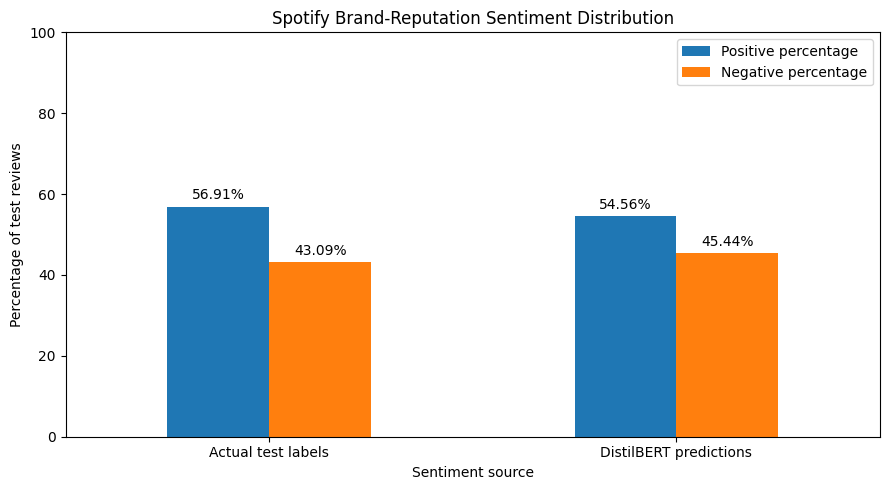

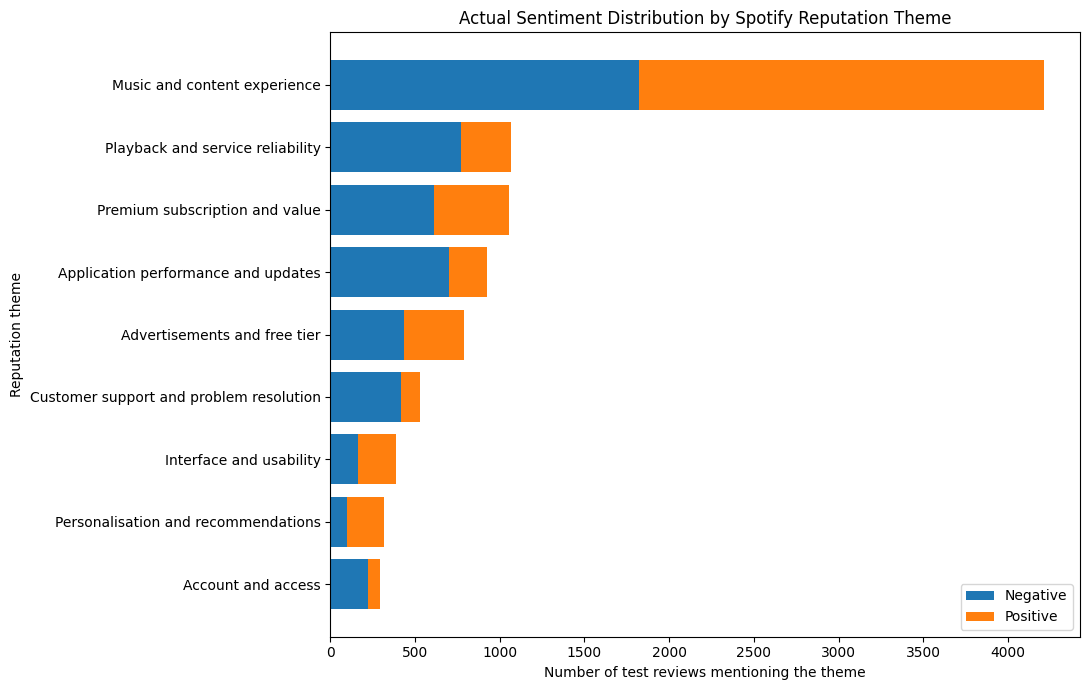

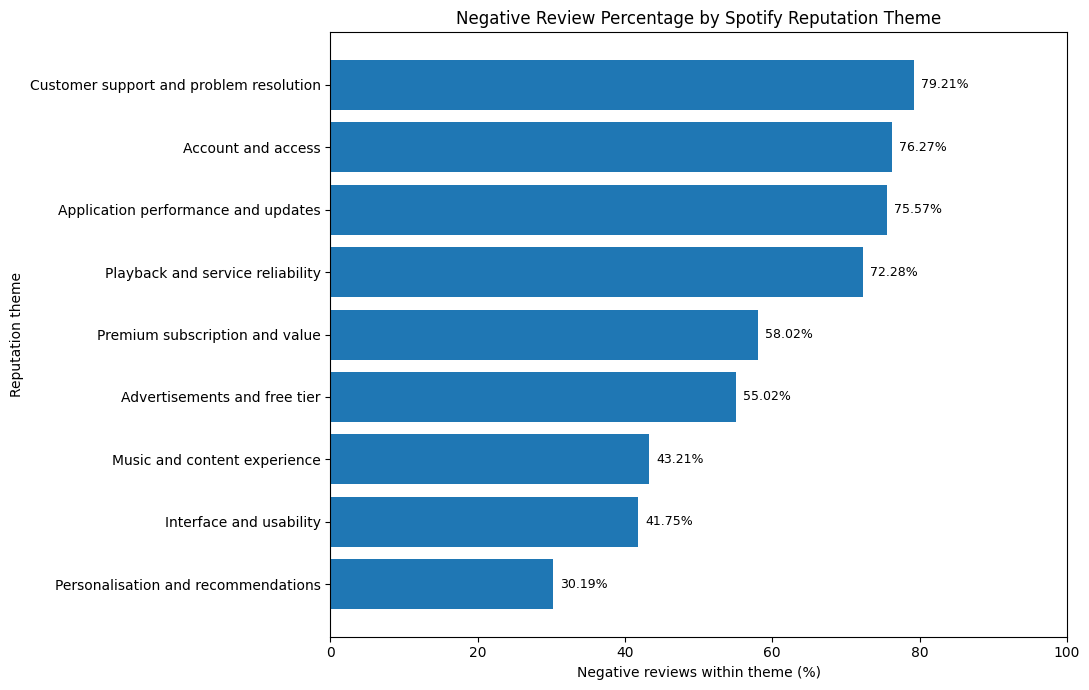

In [52]:
# 1. Actual versus predicted sentiment distribution
distribution_plot_data = (

    distilbert_overall_reputation_summary

    .set_index(
        "Sentiment source"
    )

    [
        [
            "Positive percentage",
            "Negative percentage"
        ]
    ]
)


axis = distribution_plot_data.plot(

    kind="bar",

    figsize=(9, 5)
)


axis.set_title(
    "Spotify Brand-Reputation Sentiment Distribution"
)

axis.set_xlabel(
    "Sentiment source"
)

axis.set_ylabel(
    "Percentage of test reviews"
)

axis.set_ylim(
    0,
    100
)

plt.xticks(
    rotation=0
)


for container in axis.containers:

    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )


plt.tight_layout()
plt.show()

# 2. Positive and negative counts for each theme
theme_plot_data = (

    distilbert_actual_theme_summary

    .sort_values(
        "total_mentions",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(

    theme_plot_data[
        "theme"
    ],

    theme_plot_data[
        "negative_count"
    ],

    label="Negative"
)


plt.barh(

    theme_plot_data[
        "theme"
    ],

    theme_plot_data[
        "positive_count"
    ],

    left=theme_plot_data[
        "negative_count"
    ],

    label="Positive"
)


plt.title(
    "Actual Sentiment Distribution by Spotify Reputation Theme"
)

plt.xlabel(
    "Number of test reviews mentioning the theme"
)

plt.ylabel(
    "Reputation theme"
)

plt.legend()

plt.tight_layout()
plt.show()

# 3. Negative proportion for each theme
negative_theme_plot = (

    distilbert_actual_theme_summary

    .sort_values(
        "negative_percentage",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


bars = plt.barh(

    negative_theme_plot[
        "theme"
    ],

    negative_theme_plot[
        "negative_percentage"
    ]
)


plt.xlim(
    0,
    100
)


plt.title(
    "Negative Review Percentage by Spotify Reputation Theme"
)

plt.xlabel(
    "Negative reviews within theme (%)"
)

plt.ylabel(
    "Reputation theme"
)


for bar, value in zip(

    bars,

    negative_theme_plot[
        "negative_percentage"
    ]
):

    plt.text(

        value + 1,

        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f}%",

        va="center",

        fontsize=9
    )


plt.tight_layout()
plt.show()

The visualisations answer three different questions:

1. Is the overall review sample mainly positive or negative?
2. Which Spotify themes are discussed most often?
3. Which themes contain the highest proportion of negative reviews?

The third chart is especially useful for identifying potential brand-reputation risks.

## **Representative Review Examples**

In [53]:
representative_review_parts = []


for theme_name in REPUTATION_THEMES:

    for sentiment_name in [
        NEGATIVE_LABEL,
        POSITIVE_LABEL
    ]:

        matching_reviews = (

            distilbert_theme_long[

                (
                    distilbert_theme_long[
                        "theme"
                    ]
                    == theme_name
                )

                &

                (
                    distilbert_theme_long[
                        "true_label"
                    ]
                    == sentiment_name
                )
            ]

            .copy()
        )


        if matching_reviews.empty:
            continue


        # Prioritise reviews where the model agrees with the
        # actual label and has higher confidence.
        matching_reviews = (

            matching_reviews

            .sort_values(

                [
                    "correct_prediction",
                    "confidence"
                ],

                ascending=[
                    False,
                    False
                ]
            )

            .drop_duplicates(
                subset=[
                    "review_text"
                ]
            )

            .head(2)
        )


        matching_reviews[
            "review_excerpt"
        ] = (

            matching_reviews[
                "review_text"
            ]

            .astype(str)

            .str.slice(
                0,
                220
            )
        )


        matching_reviews[
            "example_sentiment"
        ] = sentiment_name


        representative_review_parts.append(

            matching_reviews[

                [
                    "theme",
                    "example_sentiment",
                    "review_excerpt",
                    "predicted_label",
                    "confidence",
                    "correct_prediction"
                ]
            ]
        )


if representative_review_parts:

    distilbert_theme_examples = (

        pd.concat(

            representative_review_parts,

            ignore_index=True
        )
    )

else:

    distilbert_theme_examples = pd.DataFrame(

        columns=[

            "theme",
            "example_sentiment",
            "review_excerpt",
            "predicted_label",
            "confidence",
            "correct_prediction"
        ]
    )


display(
    distilbert_theme_examples
)

,theme,example_sentiment,review_excerpt,predicted_label,confidence,correct_prediction
0,Music and content experience,negative,terrible the amount of ads and limited skips h...,negative,0.995643,True
1,Music and content experience,negative,"horrible. yes, there is music that is good, bu...",negative,0.995635,True
2,Music and content experience,positive,the best music streaming service i have seen. ...,positive,0.999309,True
3,Music and content experience,positive,have had a fantastic time ever since i install...,positive,0.999288,True
4,Playback and service reliability,negative,"horrible app, only here for rogan. listen to a...",negative,0.995479,True
5,Playback and service reliability,negative,disappointing. poor integration with the sonos...,negative,0.995291,True
6,Playback and service reliability,positive,"most used app on my phone 📱 music, podcasts, o...",positive,0.999218,True
7,Playback and service reliability,positive,best music app out there. can download to my o...,positive,0.999213,True
8,Advertisements and free tier,negative,terrible the amount of ads and limited skips h...,negative,0.995643,True
9,Advertisements and free tier,negative,"horrible. yes, there is music that is good, bu...",negative,0.995635,True


* This selects up to two positive and two negative review examples for every reputation theme.

* These examples help explain what users are actually saying rather than presenting only percentages.

* The examples are based on actual sentiment labels. Reviews where the model agrees with the label are shown first.

## **Common Terms Within Each Reputation Themes**

In [54]:
ANALYSIS_STOP_WORDS = sorted(

    (
        set(
            ENGLISH_STOP_WORDS
        )

        - {
            "no",
            "not",
            "never",
            "cannot"
        }
    )

    | {
        "spotify",
        "app"
    }
)


def get_top_theme_terms(
    texts,
    top_n=8
):
    """
    Return frequent unigrams and bigrams for a group of
    review texts.
    """

    texts = (

        pd.Series(texts)

        .dropna()

        .astype(str)
    )


    if len(texts) == 0:

        return pd.DataFrame(

            columns=[
                "term",
                "frequency"
            ]
        )


    vectorizer = CountVectorizer(

        ngram_range=(
            1,
            2
        ),

        stop_words=(
            ANALYSIS_STOP_WORDS
        ),

        min_df=2,

        token_pattern=(
            r"(?u)\b"
            r"[a-zA-Z]"
            r"[a-zA-Z_']+"
            r"\b"
        )
    )


    try:

        term_matrix = (
            vectorizer.fit_transform(
                texts
            )
        )

    except ValueError:

        return pd.DataFrame(

            columns=[
                "term",
                "frequency"
            ]
        )


    terms = (
        vectorizer
        .get_feature_names_out()
    )


    frequencies = np.asarray(

        term_matrix.sum(
            axis=0
        )

    ).ravel()


    return (

        pd.DataFrame({

            "term": terms,

            "frequency": frequencies
        })

        .sort_values(

            [
                "frequency",
                "term"
            ],

            ascending=[
                False,
                True
            ]
        )

        .head(top_n)

        .reset_index(drop=True)
    )


theme_term_tables = []


for theme_name in REPUTATION_THEMES:

    for sentiment_name in [
        NEGATIVE_LABEL,
        POSITIVE_LABEL
    ]:

        selected_texts = (

            distilbert_theme_long.loc[

                (
                    distilbert_theme_long[
                        "theme"
                    ]
                    == theme_name
                )

                &

                (
                    distilbert_theme_long[
                        "true_label"
                    ]
                    == sentiment_name
                ),

                "review_text"
            ]

            .drop_duplicates()
        )


        top_terms = get_top_theme_terms(

            selected_texts,

            top_n=8
        )


        if top_terms.empty:
            continue


        top_terms.insert(
            0,
            "sentiment",
            sentiment_name
        )


        top_terms.insert(
            0,
            "theme",
            theme_name
        )


        theme_term_tables.append(
            top_terms
        )


if theme_term_tables:

    distilbert_theme_terms = pd.concat(

        theme_term_tables,

        ignore_index=True
    )

else:

    distilbert_theme_terms = pd.DataFrame(

        columns=[

            "theme",
            "sentiment",
            "term",
            "frequency"
        ]
    )


display(
    distilbert_theme_terms.head(50)
)

,theme,sentiment,term,frequency
0,Music and content experience,negative,not,1396
1,Music and content experience,negative,songs,986
2,Music and content experience,negative,song,976
3,Music and content experience,negative,music,907
4,Music and content experience,negative,play,734
5,Music and content experience,negative,cannot,497
6,Music and content experience,negative,listen,466
7,Music and content experience,negative,playlist,431
8,Music and content experience,positive,music,1801
9,Music and content experience,positive,songs,750


## **Review Length, Confidence and Theme-Error Analysis**

In [55]:
diagnostic_results = (
    distilbert_test_results_with_themes.copy()
)


# 1. Review-length analysis
diagnostic_results[
    "review_length_group"
] = pd.cut(

    diagnostic_results[
        "word_count"
    ],

    bins=[
        -1,
        1,
        3,
        6,
        10,
        20,
        40,
        np.inf
    ],

    labels=[
        "1 word",
        "2–3 words",
        "4–6 words",
        "7–10 words",
        "11–20 words",
        "21–40 words",
        "More than 40 words"
    ]
)


distilbert_length_summary = (

    diagnostic_results

    .groupby(
        "review_length_group",
        observed=False
    )

    .agg(

        review_count=(
            "correct_prediction",
            "size"
        ),

        accuracy=(
            "correct_prediction",
            "mean"
        ),

        average_confidence=(
            "confidence",
            "mean"
        )
    )

    .reset_index()
)


# 2. Confidence analysis
diagnostic_results[
    "confidence_group"
] = pd.cut(

    diagnostic_results[
        "confidence"
    ],

    bins=[
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        1.000001
    ],

    include_lowest=True,

    labels=[
        "0.50–0.60",
        "0.60–0.70",
        "0.70–0.80",
        "0.80–0.90",
        "0.90–1.00"
    ]
)


distilbert_confidence_summary = (

    diagnostic_results

    .groupby(
        "confidence_group",
        observed=False
    )

    .agg(

        prediction_count=(
            "correct_prediction",
            "size"
        ),

        accuracy=(
            "correct_prediction",
            "mean"
        ),

        average_confidence=(
            "confidence",
            "mean"
        )
    )

    .reset_index()
)


# 3. Error rate within each reputation theme

theme_review_counts = (

    distilbert_theme_long

    .groupby(
        "theme"
    )

    [
        "test_row"
    ]

    .nunique()

    .rename(
        "theme_review_count"
    )
)


theme_error_counts = (

    distilbert_theme_long[

        ~distilbert_theme_long[
            "correct_prediction"
        ]

    ]

    .groupby(
        "theme"
    )

    [
        "test_row"
    ]

    .nunique()

    .rename(
        "incorrect_review_count"
    )
)


distilbert_theme_error_summary = (

    pd.concat(

        [
            theme_review_counts,
            theme_error_counts
        ],

        axis=1
    )

    .fillna(0)

    .reset_index()
)


distilbert_theme_error_summary[
    "incorrect_review_count"
] = (

    distilbert_theme_error_summary[
        "incorrect_review_count"
    ]

    .astype(int)
)


distilbert_theme_error_summary[
    "error_rate"
] = (

    distilbert_theme_error_summary[
        "incorrect_review_count"
    ]

    / distilbert_theme_error_summary[
        "theme_review_count"
    ]

    * 100
)


distilbert_theme_error_summary = (

    distilbert_theme_error_summary

    .sort_values(
        "error_rate",
        ascending=False
    )

    .reset_index(drop=True)
)


# Error direction for each theme
distilbert_theme_error_direction = pd.crosstab(

    distilbert_theme_long.loc[

        ~distilbert_theme_long[
            "correct_prediction"
        ],

        "theme"
    ],

    distilbert_theme_long.loc[

        ~distilbert_theme_long[
            "correct_prediction"
        ],

        "error_type"
    ]
).reset_index()


print(
    "=== PERFORMANCE BY REVIEW LENGTH ==="
)

display(
    distilbert_length_summary.round(4)
)


print(
    "\n=== PERFORMANCE BY CONFIDENCE ==="
)

display(
    distilbert_confidence_summary.round(4)
)


print(
    "\n=== ERROR RATE BY REPUTATION THEME ==="
)

display(
    distilbert_theme_error_summary.round(2)
)


print(
    "\n=== ERROR DIRECTIONS BY THEME ==="
)

display(
    distilbert_theme_error_direction
)

=== PERFORMANCE BY REVIEW LENGTH ===


,review_length_group,review_count,accuracy,average_confidence
0,1 word,45,0.8667,0.9704
1,2–3 words,259,0.8996,0.9650
2,4–6 words,496,0.9597,0.9811
3,7–10 words,772,0.9469,0.9837
4,11–20 words,1572,0.9307,0.9800
5,21–40 words,1863,0.9104,0.9734
6,More than 40 words,1591,0.9221,0.9774



=== PERFORMANCE BY CONFIDENCE ===


,confidence_group,prediction_count,accuracy,average_confidence
0,0.50–0.60,40,0.4500,0.5449
1,0.60–0.70,68,0.5735,0.6539
2,0.70–0.80,75,0.6533,0.7566
3,0.80–0.90,146,0.6781,0.8599
4,0.90–1.00,6269,0.9411,0.9890



=== ERROR RATE BY REPUTATION THEME ===


,theme,theme_review_count,incorrect_review_count,error_rate
0,Customer support and problem resolution,529,62,11.72
1,Application performance and updates,925,91,9.84
2,Account and access,295,27,9.15
3,Playback and service reliability,1068,91,8.52
4,Advertisements and free tier,787,63,8.01
5,Premium subscription and value,1053,74,7.03
6,Music and content experience,4214,294,6.98
7,Interface and usability,388,16,4.12
8,Personalisation and recommendations,318,11,3.46



=== ERROR DIRECTIONS BY THEME ===


error_type,theme,negative → positive,positive → negative
0,Account and access,5,22
1,Advertisements and free tier,22,41
2,Application performance and updates,14,77
3,Customer support and problem resolution,14,48
4,Interface and usability,6,10
5,Music and content experience,100,194
6,Personalisation and recommendations,3,8
7,Playback and service reliability,25,66
8,Premium subscription and value,19,55


## **Model Diagnostic Visualisations**

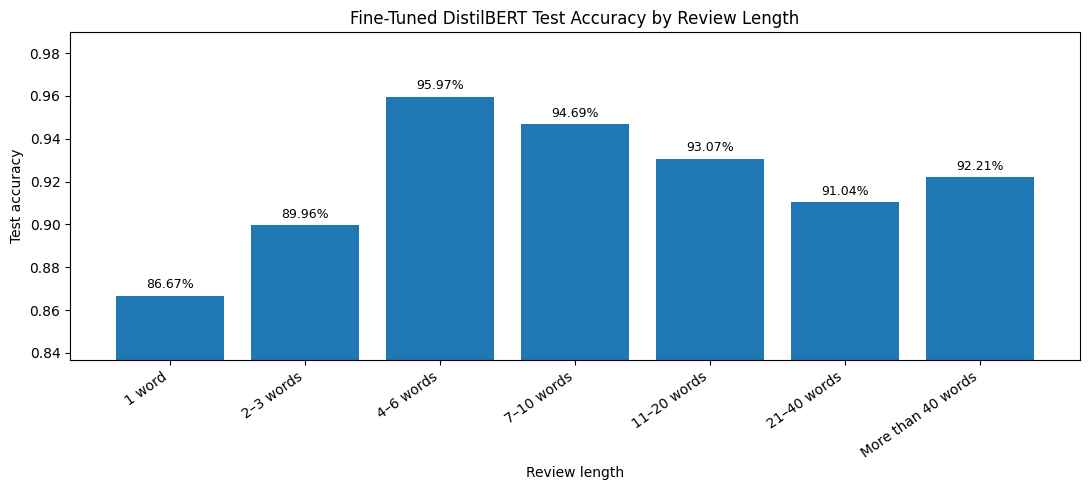

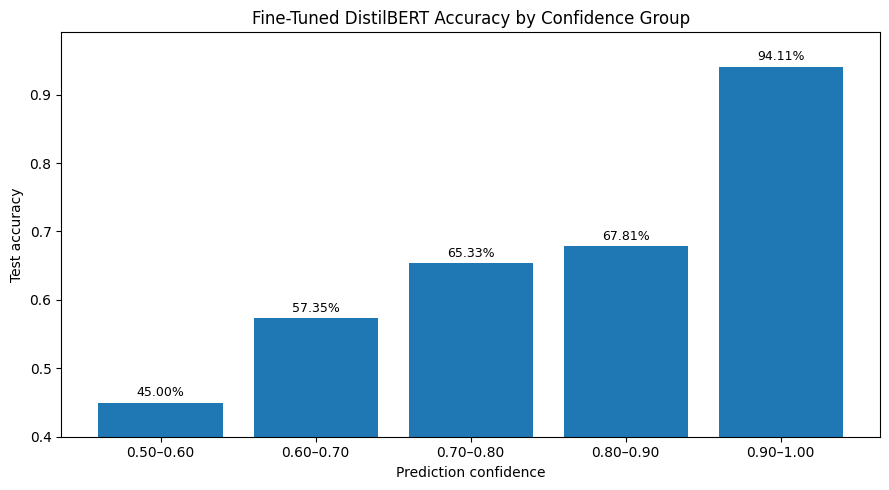

In [56]:
# 1. Accuracy by review length
length_plot_data = (

    distilbert_length_summary

    .dropna(
        subset=[
            "accuracy"
        ]
    )

    .copy()
)


length_values = (

    length_plot_data[
        "accuracy"
    ]

    .to_numpy()
)


length_y_min = max(

    0,

    length_values.min()
    - 0.03
)


length_y_max = min(

    1,

    length_values.max()
    + 0.03
)


plt.figure(
    figsize=(11, 5)
)


bars = plt.bar(

    length_plot_data[
        "review_length_group"
    ].astype(str),

    length_values
)


plt.ylim(
    length_y_min,
    length_y_max
)


plt.title(
    "Fine-Tuned DistilBERT Test Accuracy by Review Length"
)

plt.xlabel(
    "Review length"
)

plt.ylabel(
    "Test accuracy"
)

plt.xticks(
    rotation=35,
    ha="right"
)


for bar, value in zip(
    bars,
    length_values
):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.002,

        f"{value * 100:.2f}%",

        ha="center",

        va="bottom",

        fontsize=9
    )


plt.tight_layout()
plt.show()

# 2. Accuracy by confidence group
confidence_plot_data = (

    distilbert_confidence_summary

    .dropna(
        subset=[
            "accuracy"
        ]
    )

    .copy()
)


confidence_values = (

    confidence_plot_data[
        "accuracy"
    ]

    .to_numpy()
)


confidence_y_min = max(

    0,

    confidence_values.min()
    - 0.05
)


confidence_y_max = min(

    1,

    confidence_values.max()
    + 0.05
)


plt.figure(
    figsize=(9, 5)
)


bars = plt.bar(

    confidence_plot_data[
        "confidence_group"
    ].astype(str),

    confidence_values
)


plt.ylim(
    confidence_y_min,
    confidence_y_max
)


plt.title(
    "Fine-Tuned DistilBERT Accuracy by Confidence Group"
)

plt.xlabel(
    "Prediction confidence"
)

plt.ylabel(
    "Test accuracy"
)


for bar, value in zip(
    bars,
    confidence_values
):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.005,

        f"{value * 100:.2f}%",

        ha="center",

        va="bottom",

        fontsize=9
    )


plt.tight_layout()
plt.show()

## **Export Complete DistilBERT Analysis**

In [57]:
DISTILBERT_UPDATED_ANALYSIS_PATH = os.path.join(

    DISTILBERT_BASE_DIR,

    "distilbert_brand_reputation_test_analysis.xlsx"
)


DISTILBERT_UPDATED_PREDICTIONS_PATH = os.path.join(

    DISTILBERT_BASE_DIR,

    "distilbert_test_predictions_with_themes.csv"
)


# Save review-level predictions and theme indicators.
distilbert_test_results_with_themes.to_csv(

    DISTILBERT_UPDATED_PREDICTIONS_PATH,

    index=False
)


with pd.ExcelWriter(

    DISTILBERT_UPDATED_ANALYSIS_PATH,

    engine="openpyxl"

) as writer:


    # Model-evaluation outputs
    distilbert_test_summary.to_excel(

        writer,

        sheet_name="Test Summary",

        index=False
    )


    distilbert_validation_test_comparison.to_excel(

        writer,

        sheet_name="Val Test Comparison",

        index=False
    )


    distilbert_test_report_df.to_excel(

        writer,

        sheet_name="Classification Report"
    )


    # Detailed predictions
    distilbert_test_results_with_themes.to_excel(

        writer,

        sheet_name="Test Predictions",

        index=False
    )


    distilbert_wrong_predictions.to_excel(

        writer,

        sheet_name="Incorrect Predictions",

        index=False
    )


    # Brand-reputation outputs
    distilbert_theme_coverage.to_excel(

        writer,

        sheet_name="Theme Coverage",

        index=False
    )


    distilbert_actual_theme_summary.to_excel(

        writer,

        sheet_name="Actual Theme Summary",

        index=False
    )


    distilbert_predicted_theme_summary.to_excel(

        writer,

        sheet_name="Pred Theme Summary",

        index=False
    )


    distilbert_overall_reputation_summary.to_excel(

        writer,

        sheet_name="Overall Reputation",

        index=False
    )


    distilbert_theme_examples.to_excel(

        writer,

        sheet_name="Theme Examples",

        index=False
    )


    distilbert_theme_terms.to_excel(

        writer,

        sheet_name="Theme Terms",

        index=False
    )


    distilbert_theme_long.to_excel(

        writer,

        sheet_name="Review Theme Records",

        index=False
    )


    # Diagnostic outputs
    distilbert_length_summary.to_excel(

        writer,

        sheet_name="Length Analysis",

        index=False
    )


    distilbert_confidence_summary.to_excel(

        writer,

        sheet_name="Confidence Analysis",

        index=False
    )


    distilbert_theme_error_summary.to_excel(

        writer,

        sheet_name="Theme Error Summary",

        index=False
    )


    distilbert_theme_error_direction.to_excel(

        writer,

        sheet_name="Theme Error Direction",

        index=False
    )


print(
    "Updated DistilBERT test predictions saved to:"
)

print(
    DISTILBERT_UPDATED_PREDICTIONS_PATH
)


print(
    "\nUpdated brand-reputation analysis saved to:"
)

print(
    DISTILBERT_UPDATED_ANALYSIS_PATH
)

Updated DistilBERT test predictions saved to:
/content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/distilbert_test_predictions_with_themes.csv

Updated brand-reputation analysis saved to:
/content/drive/MyDrive/spotify_preprocessed_output/distilbert_binary/distilbert_brand_reputation_test_analysis.xlsx
